# Week 3 — Main Method: Full Fine-Tuning for Multimodal Transfer Learning

### Experimental Protocol
| Config | Value |
|--------|-------|
| Random seed | 42 |
| Train/Val/Test split | Provided by MedMNIST official splits |
| Optimizer | AdamW |
| Epochs | 30 |
| Image size | 224×224 (ResNet standard) |
| Batch size | 64 |
| Frameworks | PyTorch, torchvision, medmnist |

## Setup & Imports

In [27]:
!pip install medmnist torchvision scikit-learn matplotlib seaborn tqdm

In [28]:
import os
import random
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights

import medmnist
from medmnist import DermaMNIST, BloodMNIST, INFO

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    accuracy_score, f1_score
)
from sklearn.preprocessing import label_binarize

from tqdm.notebook import tqdm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('../figures', exist_ok=True)
os.makedirs('../experiments', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print(f"medmnist version: {medmnist.__version__}")
print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

Using device: cuda
GPU: Tesla T4
medmnist version: 3.0.2
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


## 1. Hyperparameters & Global Configuration

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# All hyperparameters are defined here for reproducibility and ablation ease
# ─────────────────────────────────────────────────────────────────────────────

CONFIG = {
    # Data
    'image_size': 224,          # ResNet-50 standard input
    'batch_size': 64,
    'num_workers': 2,

    # Training
    'num_epochs': 30,
    'seed': 42,

    # Full fine-tuning LR (lower than linear probing to avoid destroying pretrained weights)
    'lr_full_finetune': 1e-4,
    'lr_linear_probe': 1e-3,

    # Differential LR for fine-tuning (backbone vs classifier)
    'lr_backbone': 1e-5,
    'lr_head': 1e-3,

    # Regularization
    'weight_decay': 1e-4,
    'dropout': 0.3,

    # Scheduler
    'scheduler': 'cosine',       # 'cosine' or 'step'
    'step_size': 10,             # for StepLR
    'gamma': 0.1,                # for StepLR

    # Early stopping
    'patience': 7,
}

# Datasets to run experiments on
DATASETS = ['dermamnist', 'bloodmnist']

print("Global configuration:")
for k, v in CONFIG.items():
    print(f"  {k:30s}: {v}")

Global configuration:
  image_size                    : 224
  batch_size                    : 64
  num_workers                   : 2
  num_epochs                    : 30
  seed                          : 42
  lr_full_finetune              : 0.0001
  lr_linear_probe               : 0.001
  lr_backbone                   : 1e-05
  lr_head                       : 0.001
  weight_decay                  : 0.0001
  dropout                       : 0.3
  scheduler                     : cosine
  step_size                     : 10
  gamma                         : 0.1
  patience                      : 7


## 2. Data Loading & Transforms

In [3]:
# ── MedMNIST dataset info ─────────────────────────────────────────────────────
for ds_name in DATASETS:
    info = INFO[ds_name]
    print(f"\n{'='*55}")
    print(f"Dataset : {ds_name.upper()}")
    print(f"  Task         : {info['task']}")
    print(f"  # Classes    : {info['n_channels']} channels, {len(info['label'])} classes")
    print(f"  Labels       : {info['label']}")
    print(f"  License      : {info['license']}")


Dataset : DERMAMNIST
  Task         : multi-class
  # Classes    : 3 channels, 7 classes
  Labels       : {'0': 'actinic keratoses and intraepithelial carcinoma', '1': 'basal cell carcinoma', '2': 'benign keratosis-like lesions', '3': 'dermatofibroma', '4': 'melanoma', '5': 'melanocytic nevi', '6': 'vascular lesions'}
  License      : CC BY-NC 4.0

Dataset : BLOODMNIST
  Task         : multi-class
  # Classes    : 3 channels, 8 classes
  Labels       : {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}
  License      : CC BY 4.0


In [4]:
# ── Transforms ───────────────────────────────────────────────────────────────
# ImageNet normalization stats (used since we transfer from ImageNet-pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['image_size'], CONFIG['image_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:", train_transform)
print("\nVal/Test transform:", val_transform)

Train transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
def get_dataloaders(dataset_name, batch_size, num_workers=2):
    """Load MedMNIST dataset and return train/val/test DataLoaders."""
    dataset_map = {
        'dermamnist': DermaMNIST,
        'bloodmnist': BloodMNIST,
    }
    DatasetClass = dataset_map[dataset_name]
    info = INFO[dataset_name]
    n_classes = len(info['label'])

    train_ds = DatasetClass(split='train', transform=train_transform,
                            download=True, as_rgb=True)
    val_ds   = DatasetClass(split='val',   transform=val_transform,
                            download=True, as_rgb=True)
    test_ds  = DatasetClass(split='test',  transform=val_transform,
                            download=True, as_rgb=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)

    print(f"[{dataset_name}] Train: {len(train_ds):>5} | "
          f"Val: {len(val_ds):>5} | Test: {len(test_ds):>5} | "
          f"Classes: {n_classes}")

    return train_loader, val_loader, test_loader, n_classes, info


# Load both datasets
dataloaders = {}
for ds_name in DATASETS:
    train_loader, val_loader, test_loader, n_classes, info = \
        get_dataloaders(ds_name, CONFIG['batch_size'], CONFIG['num_workers'])
    dataloaders[ds_name] = {
        'train': train_loader, 'val': val_loader, 'test': test_loader,
        'n_classes': n_classes, 'info': info,
    }

100%|██████████| 19.7M/19.7M [00:35<00:00, 558kB/s]


[dermamnist] Train:  7007 | Val:  1003 | Test:  2005 | Classes: 7


100%|██████████| 35.5M/35.5M [00:57<00:00, 618kB/s]


[bloodmnist] Train: 11959 | Val:  1712 | Test:  3421 | Classes: 8


## 3. Model Architectures

We define three model configurations for systematic comparison:

| Config | Backbone | Layers unfrozen | LR strategy |
|---|---|---|---|
| **Linear Probing** (baseline) | ResNet-50 frozen | None | Head only |
| **Full Fine-Tuning** (main method) | ResNet-50 | All layers | Uniform low LR |
| **Differential Fine-Tuning** (ablation) | ResNet-50 | All layers | Layer-wise LR |


In [6]:
def build_model(n_classes, mode='full_finetune', dropout=0.3):
    """
    Build ResNet-50 model with different training configurations.

    Args:
        n_classes  : number of output classes
        mode       : 'linear_probe' | 'full_finetune' | 'partial_finetune'
        dropout    : dropout rate before classifier head
    """
    # Load pretrained weights (ImageNet)
    model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if mode == 'linear_probe':
        # Freeze ALL backbone layers
        for param in model.parameters():
            param.requires_grad = False

    elif mode == 'partial_finetune':
        # Freeze only early layers (layer1, layer2); unfreeze layer3, layer4
        frozen_layers = ['conv1', 'bn1', 'layer1', 'layer2']
        for name, param in model.named_parameters():
            if any(name.startswith(fl) for fl in frozen_layers):
                param.requires_grad = False

    elif mode == 'full_finetune':
        # Unfreeze ALL layers (already the default)
        for param in model.parameters():
            param.requires_grad = True

    # Replace the classifier head
    in_features = model.fc.in_features  # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, n_classes)
    )

    return model


def count_trainable_params(model):
    total  = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


# Quick sanity check
for mode in ['linear_probe', 'partial_finetune', 'full_finetune']:
    m = build_model(n_classes=7, mode=mode)
    total, trainable = count_trainable_params(m)
    pct = 100 * trainable / total
    print(f"{mode:20s} | Total: {total:>10,} | Trainable: {trainable:>10,} ({pct:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 163MB/s]


linear_probe         | Total: 23,522,375 | Trainable:     14,343 (0.1%)
partial_finetune     | Total: 23,522,375 | Trainable: 22,077,447 (93.9%)
full_finetune        | Total: 23,522,375 | Trainable: 23,522,375 (100.0%)


## 4. Training Engine

In [7]:
def get_optimizer(model, mode, config):
    """
    Return optimizer with mode-appropriate learning rates.
    For full_finetune: use differential LR (lower for backbone, higher for head).
    """
    if mode == 'linear_probe':
        # Only train the classifier head
        params = filter(lambda p: p.requires_grad, model.parameters())
        optimizer = optim.AdamW(params, lr=config['lr_linear_probe'],
                                weight_decay=config['weight_decay'])

    elif mode in ('full_finetune', 'partial_finetune'):
        # Differential learning rate: backbone gets lower LR
        head_params    = list(model.fc.parameters())
        head_ids       = set(id(p) for p in head_params)
        backbone_params = [p for p in model.parameters()
                           if id(p) not in head_ids and p.requires_grad]
        optimizer = optim.AdamW([
            {'params': backbone_params, 'lr': config['lr_backbone']},
            {'params': head_params,     'lr': config['lr_head']},
        ], weight_decay=config['weight_decay'])

    return optimizer


def get_scheduler(optimizer, config, n_epochs):
    if config['scheduler'] == 'cosine':
        return CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=1e-7)
    elif config['scheduler'] == 'step':
        return StepLR(optimizer, step_size=config['step_size'],
                      gamma=config['gamma'])
    return None


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += inputs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.squeeze().long().to(device)

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * inputs.size(0)
        probs = torch.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total   += inputs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    avg_loss = total_loss / total
    acc = correct / total
    return avg_loss, acc, np.array(all_preds), np.array(all_labels), np.array(all_probs)


def train_model(model, train_loader, val_loader, config, mode,
                n_epochs=None, device=DEVICE, exp_name='exp'):
    """
    Full training loop with early stopping and history tracking.
    Returns trained model and history dict.
    """
    if n_epochs is None:
        n_epochs = config['num_epochs']

    criterion = nn.CrossEntropyLoss()
    optimizer = get_optimizer(model, mode, config)
    scheduler = get_scheduler(optimizer, config, n_epochs)

    model = model.to(device)

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc': [],
        'lr': [],
    }

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    start_time = time.time()
    print(f"\n{'─'*60}")
    print(f"  Training: {exp_name}  |  Mode: {mode}  |  Epochs: {n_epochs}")
    print(f"{'─'*60}")
    print(f"{'Epoch':>6} {'TrainLoss':>10} {'TrainAcc':>10} "
          f"{'ValLoss':>10} {'ValAcc':>10} {'LR':>10}")
    print(f"{'─'*60}")

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion,
                                        optimizer, device)
        v_loss, v_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

        # Get current LR (head LR if differential)
        current_lr = optimizer.param_groups[-1]['lr']

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        history['lr'].append(current_lr)

        if scheduler:
            scheduler.step()

        # Early stopping & best model checkpoint
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            marker = ' ★'
        else:
            patience_counter += 1
            marker = ''

        if epoch % 5 == 0 or epoch == 1 or marker:
            print(f"{epoch:>6} {t_loss:>10.4f} {t_acc:>10.4f} "
                  f"{v_loss:>10.4f} {v_acc:>10.4f} {current_lr:>10.2e}{marker}")

        if patience_counter >= config['patience']:
            print(f"  → Early stopping at epoch {epoch} (patience={config['patience']})")
            break

    elapsed = time.time() - start_time
    print(f"{'─'*60}")
    print(f"  Best Val Acc: {best_val_acc:.4f} | Training time: {elapsed:.1f}s")

    # Restore best weights
    model.load_state_dict(best_model_wts)

    # Save checkpoint
    torch.save(best_model_wts, f'../models/{exp_name}_best.pth')

    return model, history

print("Training engine defined.")

Training engine defined.


## 5. Experiment 1 — Linear Probing vs Full Fine-Tuning (Both Datasets)

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Run: Linear Probing (Week 2 baseline) + Full Fine-Tuning (Week 3 main method)
# on both DermaMNIST and BloodMNIST
# ─────────────────────────────────────────────────────────────────────────────

EXPERIMENTS = [
    {'dataset': 'dermamnist', 'mode': 'linear_probe'},
    {'dataset': 'dermamnist', 'mode': 'full_finetune'},
    {'dataset': 'bloodmnist', 'mode': 'linear_probe'},
    {'dataset': 'bloodmnist', 'mode': 'full_finetune'},
]

all_results   = {}   # test metrics per experiment
all_histories = {}   # training histories
all_models    = {}   # trained model objects

for exp in EXPERIMENTS:
    ds_name = exp['dataset']
    mode    = exp['mode']
    exp_key = f"{ds_name}__{mode}"

    train_loader = dataloaders[ds_name]['train']
    val_loader   = dataloaders[ds_name]['val']
    test_loader  = dataloaders[ds_name]['test']
    n_classes    = dataloaders[ds_name]['n_classes']
    info         = dataloaders[ds_name]['info']

    # Reset seed per experiment for fair comparison
    torch.manual_seed(SEED)

    model = build_model(n_classes=n_classes, mode=mode, dropout=CONFIG['dropout'])

    trained_model, history = train_model(
        model, train_loader, val_loader,
        config=CONFIG,
        mode=mode,
        n_epochs=CONFIG['num_epochs'],
        device=DEVICE,
        exp_name=exp_key
    )

    # Test evaluation
    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, preds, labels, probs = \
        evaluate(trained_model, test_loader, criterion, DEVICE)

    # Multi-class AUC (OvR)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))
    try:
        auc_score = roc_auc_score(labels_bin, probs, multi_class='ovr',
                                  average='macro')
    except ValueError:
        auc_score = float('nan')

    f1 = f1_score(labels, preds, average='macro', zero_division=0)

    all_results[exp_key]   = {
        'test_loss': test_loss, 'test_acc': test_acc,
        'auc': auc_score, 'f1_macro': f1,
        'preds': preds, 'labels': labels, 'probs': probs,
        'n_classes': n_classes, 'class_names': list(info['label'].values()),
        'dataset': ds_name, 'mode': mode,
    }
    all_histories[exp_key] = history
    all_models[exp_key]    = trained_model

    print(f"\n[TEST] {exp_key:40s}  Acc={test_acc:.4f}  AUC={auc_score:.4f}  F1={f1:.4f}")


────────────────────────────────────────────────────────────
  Training: dermamnist__linear_probe  |  Mode: linear_probe  |  Epochs: 30
────────────────────────────────────────────────────────────
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc         LR
────────────────────────────────────────────────────────────
     1     1.0306     0.6690     0.8891     0.7059   1.00e-03 ★
     2     0.8825     0.6940     0.8400     0.7168   9.97e-04 ★
     3     0.8393     0.7056     0.8137     0.7218   9.89e-04 ★
     5     0.7955     0.7071     0.7781     0.7298   9.57e-04 ★
     6     0.7886     0.7157     0.7712     0.7398   9.33e-04 ★
     7     0.7755     0.7187     0.7711     0.7438   9.05e-04 ★
     8     0.7757     0.7164     0.7536     0.7527   8.72e-04 ★
    10     0.7594     0.7241     0.7602     0.7458   7.94e-04
    15     0.7391     0.7297     0.7373     0.7507   5.52e-04
  → Early stopping at epoch 15 (patience=7)
────────────────────────────────────────────────────────────
  

## 6. Ablation Study: Partial Fine-Tuning & Differential LR

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# Ablation 1: Partial Fine-Tuning (unfreeze only last 2 blocks)
#   → Tests whether we need to retrain the full backbone
# Ablation 2: Full Fine-Tuning WITHOUT differential LR (uniform low LR)
# ─────────────────────────────────────────────────────────────────────────────

ABLATION_EXPERIMENTS = [
    {'dataset': 'dermamnist', 'mode': 'partial_finetune'},
    {'dataset': 'bloodmnist', 'mode': 'partial_finetune'},
]

for exp in ABLATION_EXPERIMENTS:
    ds_name = exp['dataset']
    mode    = exp['mode']
    exp_key = f"{ds_name}__{mode}"

    train_loader = dataloaders[ds_name]['train']
    val_loader   = dataloaders[ds_name]['val']
    test_loader  = dataloaders[ds_name]['test']
    n_classes    = dataloaders[ds_name]['n_classes']
    info         = dataloaders[ds_name]['info']

    torch.manual_seed(SEED)
    model = build_model(n_classes=n_classes, mode=mode, dropout=CONFIG['dropout'])

    trained_model, history = train_model(
        model, train_loader, val_loader,
        config=CONFIG, mode=mode,
        n_epochs=CONFIG['num_epochs'],
        device=DEVICE, exp_name=exp_key
    )

    criterion = nn.CrossEntropyLoss()
    test_loss, test_acc, preds, labels, probs = \
        evaluate(trained_model, test_loader, criterion, DEVICE)

    labels_bin = label_binarize(labels, classes=list(range(n_classes)))
    try:
        auc_score = roc_auc_score(labels_bin, probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_score = float('nan')

    f1 = f1_score(labels, preds, average='macro', zero_division=0)

    all_results[exp_key]   = {
        'test_loss': test_loss, 'test_acc': test_acc,
        'auc': auc_score, 'f1_macro': f1,
        'preds': preds, 'labels': labels, 'probs': probs,
        'n_classes': n_classes, 'class_names': list(info['label'].values()),
        'dataset': ds_name, 'mode': mode,
    }
    all_histories[exp_key] = history
    all_models[exp_key]    = trained_model

    print(f"\n[TEST] {exp_key:40s}  Acc={test_acc:.4f}  AUC={auc_score:.4f}  F1={f1:.4f}")


────────────────────────────────────────────────────────────
  Training: dermamnist__partial_finetune  |  Mode: partial_finetune  |  Epochs: 30
────────────────────────────────────────────────────────────
 Epoch  TrainLoss   TrainAcc    ValLoss     ValAcc         LR
────────────────────────────────────────────────────────────
     1     0.9894     0.6702     0.8439     0.7178   1.00e-03 ★
     2     0.8139     0.7054     0.7764     0.7298   9.97e-04 ★
     3     0.7583     0.7233     0.7391     0.7408   9.89e-04 ★
     5     0.6980     0.7374     0.6958     0.7448   9.57e-04 ★
     6     0.6853     0.7451     0.6892     0.7577   9.33e-04 ★
     8     0.6604     0.7514     0.6528     0.7687   8.72e-04 ★
    10     0.6351     0.7600     0.6641     0.7547   7.94e-04
    12     0.6243     0.7632     0.6421     0.7697   7.03e-04 ★
    15     0.5917     0.7725     0.6371     0.7707   5.52e-04 ★
    20     0.5739     0.7828     0.6404     0.7647   2.97e-04
  → Early stopping at epoch 22 (pat

## 7. Results Summary Table

In [18]:
# ── Build summary DataFrame ───────────────────────────────────────────────────
rows = []
for key, r in all_results.items():
    rows.append({
        'Experiment': key,
        'Dataset': r['dataset'].upper(),
        'Method': r['mode'].replace('_', ' ').title(),
        'Test Accuracy': f"{r['test_acc']:.4f}",
        'Macro AUC-ROC': f"{r['auc']:.4f}",
        'Macro F1': f"{r['f1_macro']:.4f}",
        'Test Loss': f"{r['test_loss']:.4f}",
    })

df_results = pd.DataFrame(rows)
df_results = df_results.sort_values(['Dataset', 'Method'])

print("\n" + "="*70)
print("RESULTS SUMMARY — All Experiments")
print("="*70)
print(df_results.to_string(index=False))

# Save to CSV for experiments/ folder
df_results.to_csv('../experiments/W3_results_summary.csv', index=False)
print("\nSaved: ../experiments/W3_results_summary.csv")


RESULTS SUMMARY — All Experiments
                  Experiment    Dataset           Method Test Accuracy Macro AUC-ROC Macro F1 Test Loss
   bloodmnist__full_finetune BLOODMNIST    Full Finetune        0.9605        0.9980   0.9569    0.1126
    bloodmnist__linear_probe BLOODMNIST     Linear Probe        0.7822        0.9683   0.7417    0.6325
bloodmnist__partial_finetune BLOODMNIST Partial Finetune        0.9421        0.9963   0.9357    0.1668
   dermamnist__full_finetune DERMAMNIST    Full Finetune        0.7676        0.9268   0.5474    0.6301
    dermamnist__linear_probe DERMAMNIST     Linear Probe        0.7312        0.8922   0.4116    0.7584
dermamnist__partial_finetune DERMAMNIST Partial Finetune        0.7546        0.9287   0.4930    0.6378

Saved: ../experiments/W3_results_summary.csv


## 8. Figures

### 8.1 Learning Curves (Loss & Accuracy)

Saved: ../figures/W3_learning_curves_dermamnist.png


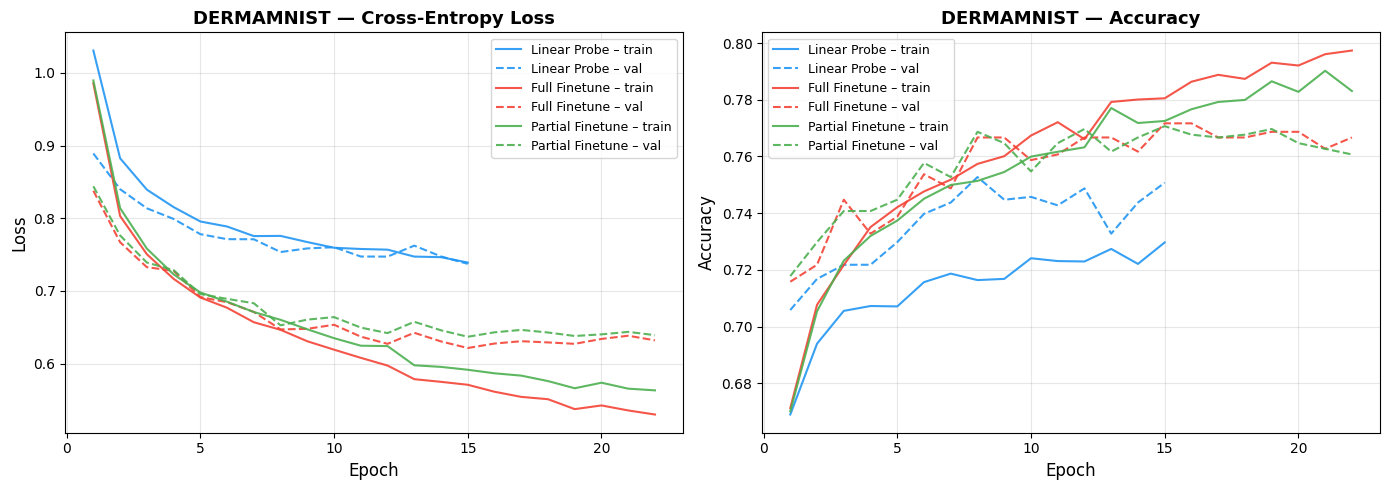

Saved: ../figures/W3_learning_curves_bloodmnist.png


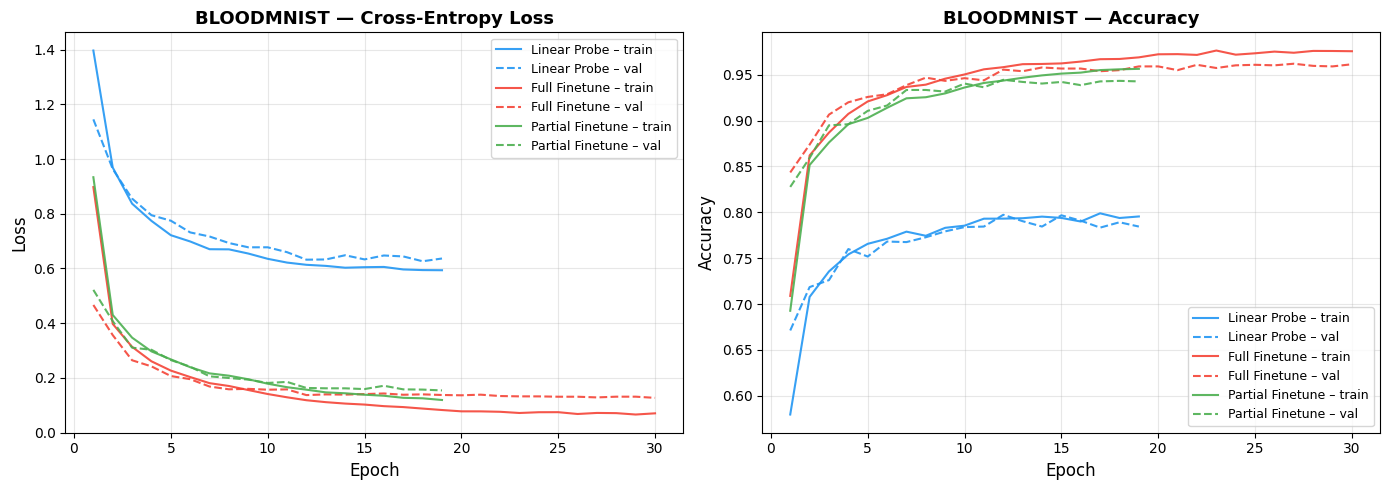

In [19]:
def plot_learning_curves(histories, dataset_name, methods, save_path=None):
    """
    Plot train/val loss and accuracy curves for multiple methods on one dataset.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800']
    linestyles_train = ['-',  '-',  '-',  '-']
    linestyles_val   = ['--', '--', '--', '--']

    for i, method in enumerate(methods):
        key  = f"{dataset_name}__{method}"
        if key not in histories:
            continue
        h    = histories[key]
        eps  = range(1, len(h['train_loss']) + 1)
        lbl  = method.replace('_', ' ').title()
        c    = colors[i % len(colors)]

        # Loss
        axes[0].plot(eps, h['train_loss'], color=c, ls='-',  alpha=0.9,
                     label=f'{lbl} – train')
        axes[0].plot(eps, h['val_loss'],   color=c, ls='--', alpha=0.9,
                     label=f'{lbl} – val')

        # Accuracy
        axes[1].plot(eps, h['train_acc'], color=c, ls='-',  alpha=0.9,
                     label=f'{lbl} – train')
        axes[1].plot(eps, h['val_acc'],   color=c, ls='--', alpha=0.9,
                     label=f'{lbl} – val')

    for ax, title, ylabel in zip(
        axes,
        [f'{dataset_name.upper()} — Cross-Entropy Loss',
         f'{dataset_name.upper()} — Accuracy'],
        ['Loss', 'Accuracy']
    ):
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Plot for both datasets
for ds in DATASETS:
    plot_learning_curves(
        all_histories, ds,
        methods=['linear_probe', 'full_finetune', 'partial_finetune'],
        save_path=f'../figures/W3_learning_curves_{ds}.png'
    )

### 8.2 Confusion Matrices

Saved: ../figures/W3_confusion_matrix_dermamnist_full_finetune.png


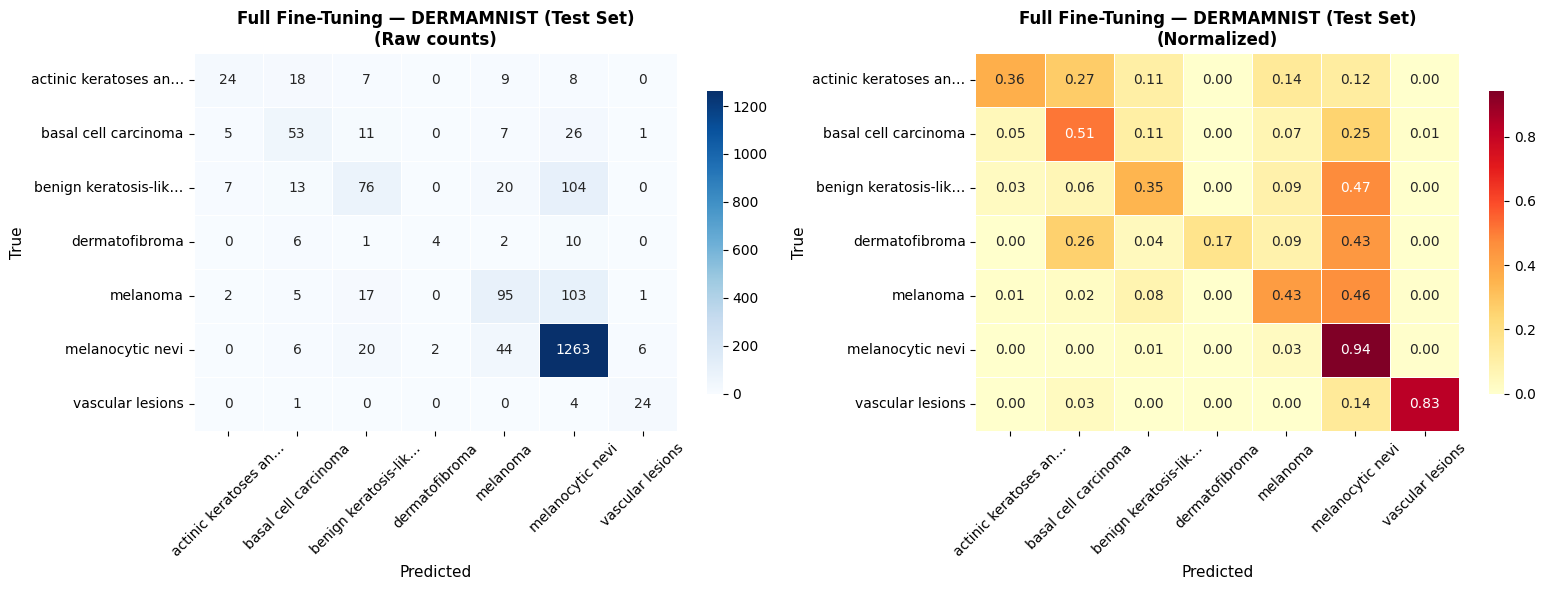

Saved: ../figures/W3_confusion_matrix_bloodmnist_full_finetune.png


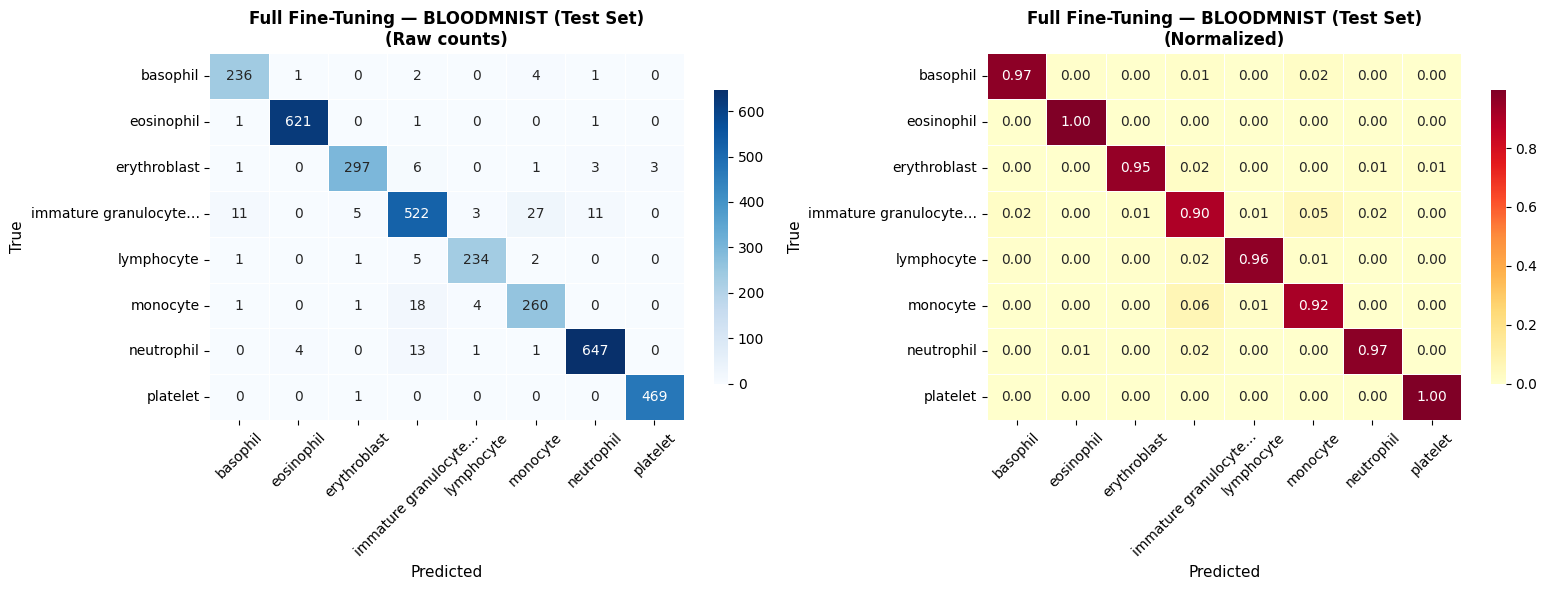

In [20]:
def plot_confusion_matrix(preds, labels, class_names, title, save_path=None):
    MAX_LEN = 20
    class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c for c in class_names]

    cm = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, data, fmt, cmap, subtitle in zip(
        axes,
        [cm, cm_norm],
        ['d', '.2f'],
        ['Blues', 'YlOrRd'],
        ['Raw counts', 'Normalized']
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap=cmap,
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8}
        )
        ax.set_xlabel('Predicted', fontsize=11)
        ax.set_ylabel('True', fontsize=11)
        ax.set_title(f'{title}\n({subtitle})', fontsize=12, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='y', rotation=0)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# Plot CM for both datasets — full fine-tuning method
for ds in DATASETS:
    key = f"{ds}__full_finetune"
    r   = all_results[key]
    plot_confusion_matrix(
        r['preds'], r['labels'], r['class_names'],
        title=f"Full Fine-Tuning — {ds.upper()} (Test Set)",
        save_path=f'../figures/W3_confusion_matrix_{ds}_full_finetune.png'
    )

### 8.3 Multi-Class ROC Curves

Saved: ../figures/W3_roc_dermamnist_full_finetune.png


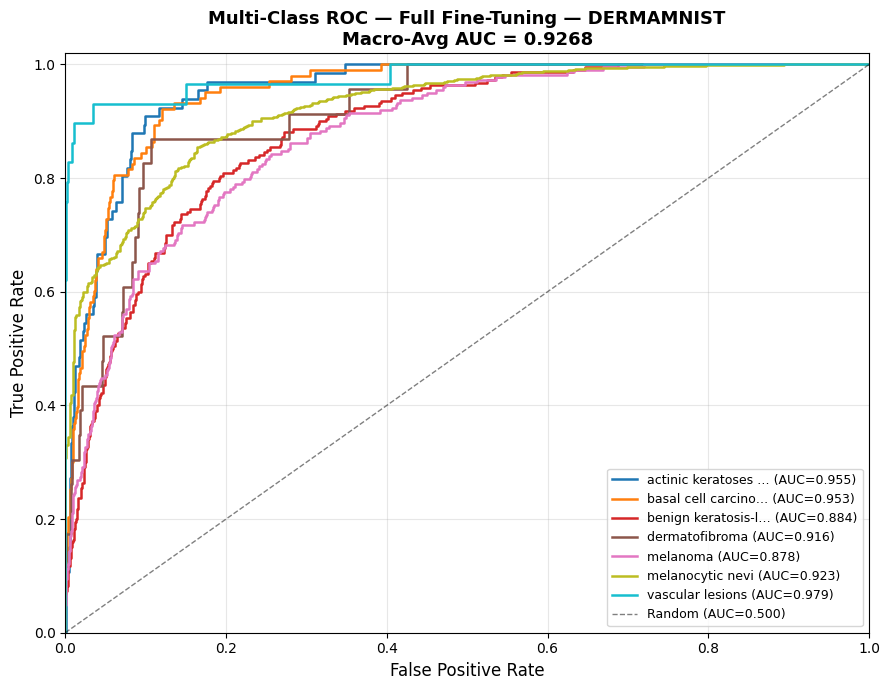

Saved: ../figures/W3_roc_bloodmnist_full_finetune.png


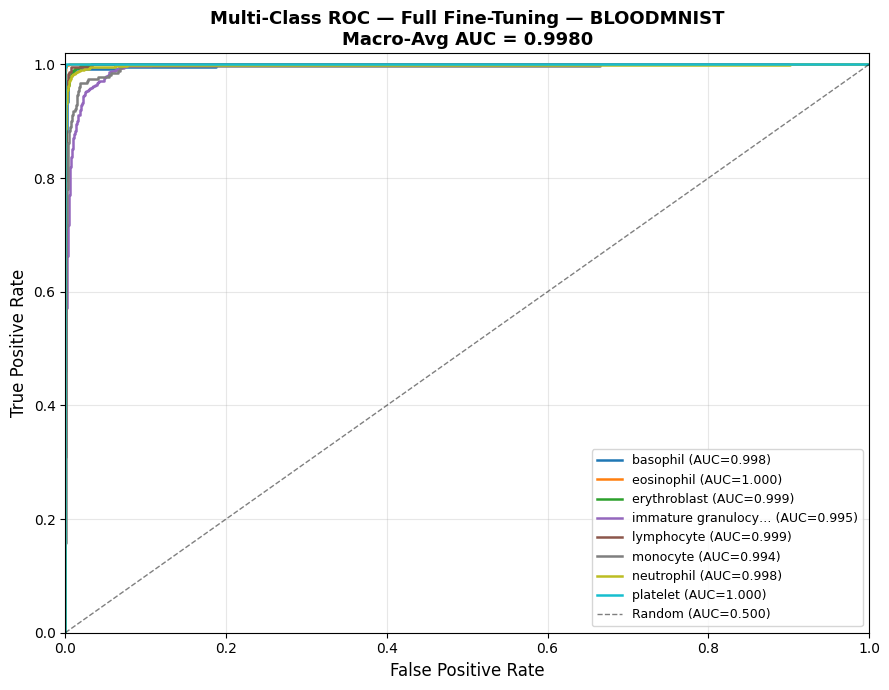

In [22]:
def plot_multiclass_roc(probs, labels, class_names, title, save_path=None):
    n_classes = len(class_names)
    labels_bin = label_binarize(labels, classes=list(range(n_classes)))

    fig, ax = plt.subplots(figsize=(9, 7))

    colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
    macro_auc = []

    for i, (cls_name, color) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        roc_auc = auc(fpr, tpr)
        macro_auc.append(roc_auc)
        short_name = cls_name[:18] + '…' if len(cls_name) > 18 else cls_name
        ax.plot(fpr, tpr, color=color, lw=1.8,
                label=f'{short_name} (AUC={roc_auc:.3f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.500)')

    avg_auc = np.mean(macro_auc)
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title(f'{title}\nMacro-Avg AUC = {avg_auc:.4f}',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.02])

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


# ROC for full fine-tuning on both datasets
for ds in DATASETS:
    key = f"{ds}__full_finetune"
    r   = all_results[key]
    plot_multiclass_roc(
        r['probs'], r['labels'], r['class_names'],
        title=f"Multi-Class ROC — Full Fine-Tuning — {ds.upper()}",
        save_path=f'../figures/W3_roc_{ds}_full_finetune.png'
    )

### 8.4 Bar Chart Comparison — All Methods

Saved: ../figures/W3_comparison_accuracy.png


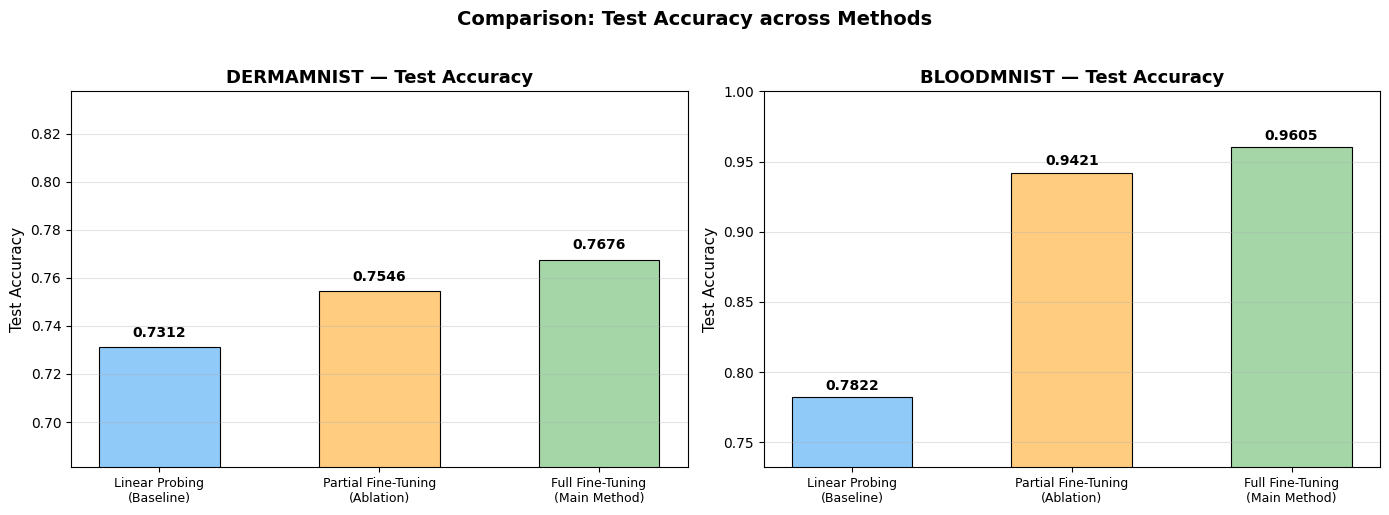

Saved: ../figures/W3_comparison_auc.png


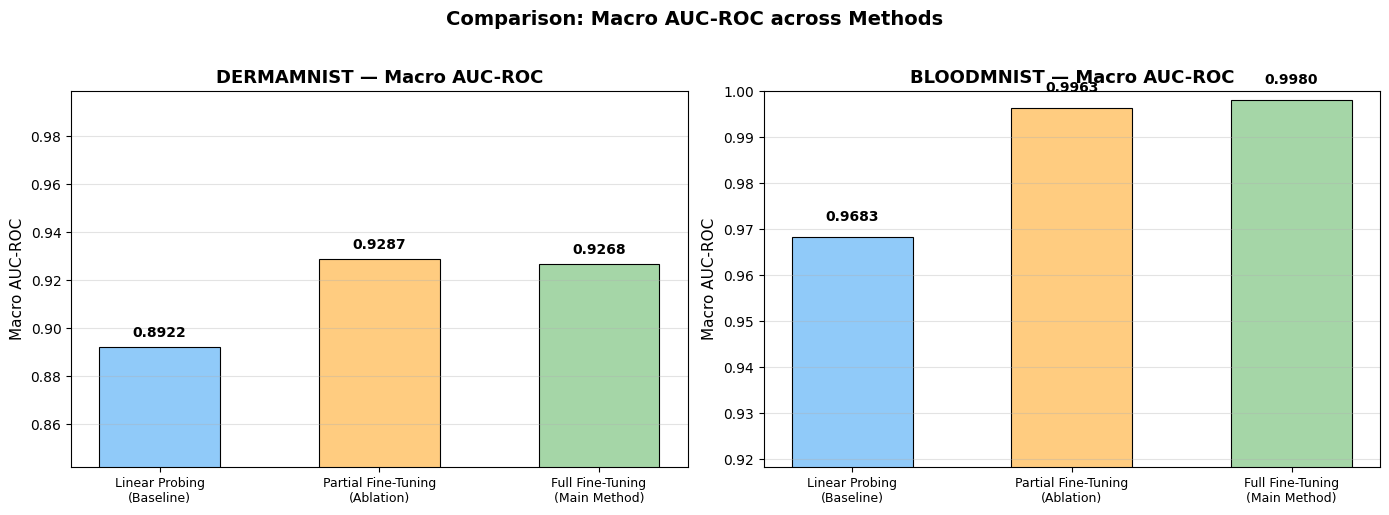

Saved: ../figures/W3_comparison_f1.png


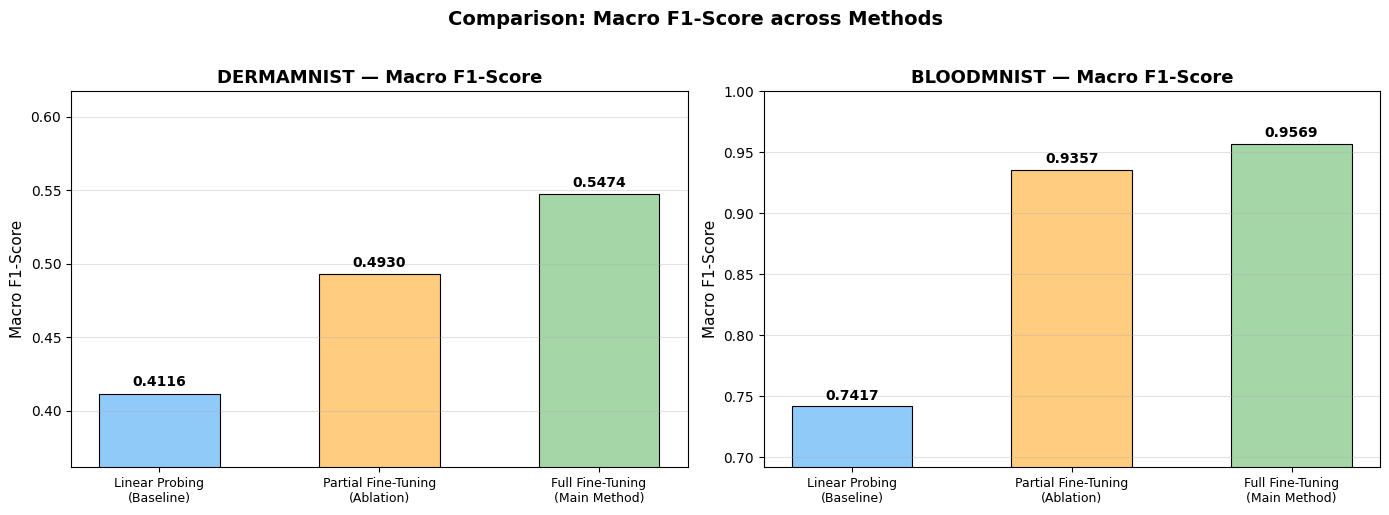

In [23]:
def plot_metric_comparison(all_results, metric='test_acc', metric_label='Test Accuracy',
                           save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

    method_order = ['linear_probe', 'partial_finetune', 'full_finetune']
    method_labels = ['Linear Probing\n(Baseline)',
                     'Partial Fine-Tuning\n(Ablation)',
                     'Full Fine-Tuning\n(Main Method)']
    colors = ['#90CAF9', '#FFCC80', '#A5D6A7']

    for ax, ds in zip(axes, DATASETS):
        values, x_labels, bar_colors = [], [], []
        for method, lbl, c in zip(method_order, method_labels, colors):
            key = f"{ds}__{method}"
            if key in all_results:
                values.append(all_results[key][metric])
                x_labels.append(lbl)
                bar_colors.append(c)

        bars = ax.bar(x_labels, values, color=bar_colors, edgecolor='black',
                      linewidth=0.8, width=0.55)

        # Annotate values
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=10,
                    fontweight='bold')

        ax.set_title(f'{ds.upper()} — {metric_label}',
                     fontsize=13, fontweight='bold')
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_ylim([max(0, min(values) - 0.05), min(1, max(values) + 0.07)])
        ax.grid(axis='y', alpha=0.35)
        ax.tick_params(axis='x', labelsize=9)

    plt.suptitle(f'Comparison: {metric_label} across Methods',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


plot_metric_comparison(all_results, metric='test_acc', metric_label='Test Accuracy',
                       save_path='../figures/W3_comparison_accuracy.png')

plot_metric_comparison(all_results, metric='auc', metric_label='Macro AUC-ROC',
                       save_path='../figures/W3_comparison_auc.png')

plot_metric_comparison(all_results, metric='f1_macro', metric_label='Macro F1-Score',
                       save_path='../figures/W3_comparison_f1.png')

### 8.5 Per-Class F1 Score Heatmap

Saved: ../figures/W3_perclass_f1_dermamnist.png


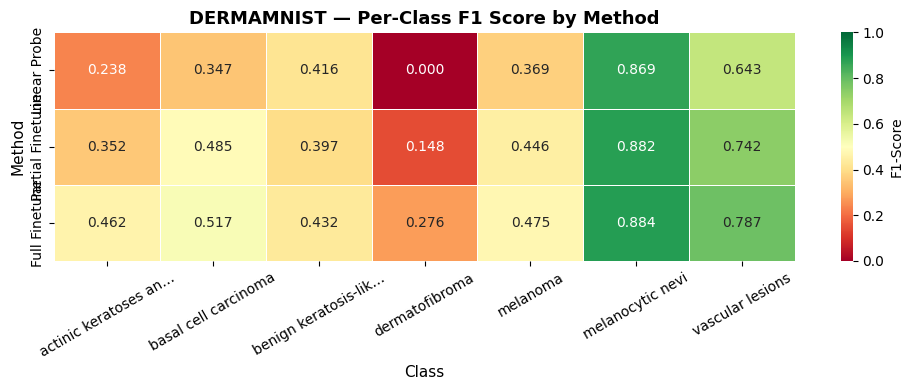

Saved: ../figures/W3_perclass_f1_bloodmnist.png


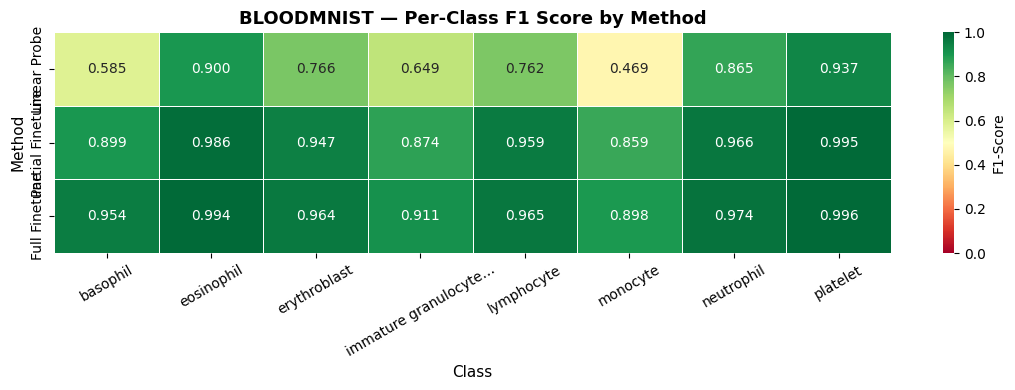

In [24]:
def plot_perclass_f1(all_results, dataset_name, methods, save_path=None):
    method_labels = [m.replace('_', ' ').title() for m in methods]
    class_names = None
    f1_matrix = []

    for method in methods:
        key = f"{dataset_name}__{method}"
        if key not in all_results:
            continue
        r = all_results[key]
        if class_names is None:
            MAX_LEN = 20
            class_names = [c[:MAX_LEN] + '…' if len(c) > MAX_LEN else c
                           for c in r['class_names']]
        report = classification_report(
            r['labels'], r['preds'],
            target_names=class_names, output_dict=True, zero_division=0
        )
        f1_per_class = [report[cn]['f1-score'] for cn in class_names]
        f1_matrix.append(f1_per_class)

    df_f1 = pd.DataFrame(f1_matrix, index=method_labels, columns=class_names)

    fig, ax = plt.subplots(figsize=(max(10, len(class_names)*1.4), 4))
    sns.heatmap(df_f1, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=0, vmax=1, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'F1-Score'})
    ax.set_title(f'{dataset_name.upper()} — Per-Class F1 Score by Method',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=11)
    ax.set_ylabel('Method', fontsize=11)
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {save_path}")
    plt.show()


for ds in DATASETS:
    plot_perclass_f1(
        all_results, ds,
        methods=['linear_probe', 'partial_finetune', 'full_finetune'],
        save_path=f'../figures/W3_perclass_f1_{ds}.png'
    )

## 9. Detailed Classification Reports

In [25]:
for key, r in all_results.items():
    print(f"\n{'='*65}")
    print(f" Classification Report: {key}")
    print(f"{'='*65}")
    print(classification_report(
        r['labels'], r['preds'],
        target_names=r['class_names'], zero_division=0
    ))
    print(f" Test Accuracy : {r['test_acc']:.4f}")
    print(f" Macro AUC-ROC : {r['auc']:.4f}")
    print(f" Macro F1      : {r['f1_macro']:.4f}")


 Classification Report: dermamnist__linear_probe
                                                 precision    recall  f1-score   support

actinic keratoses and intraepithelial carcinoma       0.56      0.15      0.24        66
                           basal cell carcinoma       0.55      0.25      0.35       103
                  benign keratosis-like lesions       0.48      0.36      0.42       220
                                 dermatofibroma       0.00      0.00      0.00        23
                                       melanoma       0.39      0.35      0.37       223
                               melanocytic nevi       0.81      0.93      0.87      1341
                               vascular lesions       0.67      0.62      0.64        29

                                       accuracy                           0.73      2005
                                      macro avg       0.49      0.38      0.41      2005
                                   weighted avg       0.70

## 10. Save All Experiment Logs

In [26]:
# Save per-epoch histories to CSV
for key, h in all_histories.items():
    df_hist = pd.DataFrame({
        'epoch':      list(range(1, len(h['train_loss']) + 1)),
        'train_loss': h['train_loss'],
        'train_acc':  h['train_acc'],
        'val_loss':   h['val_loss'],
        'val_acc':    h['val_acc'],
        'lr':         h['lr'],
    })
    path = f'../experiments/history_{key}.csv'
    df_hist.to_csv(path, index=False)
    print(f"Saved: {path}")

# Final summary table
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(df_results.to_string(index=False))
print("\nAll figures saved to ../figures/")
print("All experiment logs saved to ../experiments/")
print("All model checkpoints saved to ../models/")

Saved: ../experiments/history_dermamnist__linear_probe.csv
Saved: ../experiments/history_dermamnist__full_finetune.csv
Saved: ../experiments/history_bloodmnist__linear_probe.csv
Saved: ../experiments/history_bloodmnist__full_finetune.csv
Saved: ../experiments/history_dermamnist__partial_finetune.csv
Saved: ../experiments/history_bloodmnist__partial_finetune.csv

FINAL RESULTS SUMMARY
                  Experiment    Dataset           Method Test Accuracy Macro AUC-ROC Macro F1 Test Loss
   bloodmnist__full_finetune BLOODMNIST    Full Finetune        0.9605        0.9980   0.9569    0.1126
    bloodmnist__linear_probe BLOODMNIST     Linear Probe        0.7822        0.9683   0.7417    0.6325
bloodmnist__partial_finetune BLOODMNIST Partial Finetune        0.9421        0.9963   0.9357    0.1668
   dermamnist__full_finetune DERMAMNIST    Full Finetune        0.7676        0.9268   0.5474    0.6301
    dermamnist__linear_probe DERMAMNIST     Linear Probe        0.7312        0.8922   0.4116